# Genetic Algorithm Assignment
30% of the overall grade for this module

Marks indciated in sections below are based on percentage of marks allocated for this module

In this assignment you must choose a problem, and attempt to use the Genetic Alogrithm that we developed in class to solve this problem.

The choice of problem has to be discussed and agreed with the lecturer.

Progression of the assignment must be demonstrated continuously throughout the semester.

Final version must be demonstrated in class before submission date.

Failure to adhere to all of the above, without express permission of the lecturer will severely impact your grade.



## The Problem         **(~30%)**

*   Description of the problem





---

The training of machine learning models can be influenced by 'hyperparameters,' to make trained models faster, less prone to overfitting, and generally more effective. Finding the perfect hyperparamters, however, is often a case of trial-and-error. This project attempts to utilize the genetic algorthim to find the best hyperparameters by repeatedly training gradient descent regression models on a small sample of data.

---



*   Discussion of the suitablity of Genetic Algorithms


---

Hyperparameter optimization is unavoidably a 'trial-and-error' problem. The result of a model training with specific hyperparameters on a dataset are unknown until the training is complete, and trying every single combination of many hyperparameters would take a vast amount of time and computational power. 

---



*   Complexity of the problem  (Overall marks allocated based on ..)

# Dependencies and Util **(~0%)**

Penalty and learning-rate options are defined at [scikit-learn/SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#r4f447a970fb6-1).

In [310]:
import time
from enum import Enum
from copy import deepcopy

import pandas as pd
import numpy as np

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.preprocessing import StandardScaler

learning_rate_map = ["constant", "optimal", "invscaling", "adaptive"]
regularization_rate_map = ["l2", "l1", "elasticnet", None]

RANDOM_SEED = 100 # Using reproducible random numbers for testing
random = np.random.default_rng(RANDOM_SEED)

def clip_arr(arr, mins, maxs):
    for i in range(len(arr)):
        arr[i] = np.clip(arr[i], mins[i], maxs[i])

# The problem and the cost function   **(~20%)**

In order to define the cost function, a sample of a dataset must be created to train with using each individual's hyperparameters.

In [311]:
COL_X_LABEL = 'x'
COL_Y_LABEL = 'y'

SAMPLE_SIZE = 1 # The % of the dataset used to evaluate each individual's model

# Load dataset
dataset = pd.read_csv('../datasets/simple.csv', header=0, usecols=['x', 'y'], names=[COL_X_LABEL, COL_Y_LABEL])

# Sample data

dataset_sampled = dataset.sample(frac=SAMPLE_SIZE, random_state=RANDOM_SEED)

# Normalize data

scaler = StandardScaler()
data_scaled = scaler.fit_transform(dataset_sampled[[COL_X_LABEL, COL_Y_LABEL]])

    # First 80% is training, next 20% is testing
train_data, test_data = np.split(data_scaled, [int(.8 * len(data_scaled))])
train_data, test_data = train_data.T, test_data.T

# Define cost function

def cost(chromosome):
    model = SGDRegressor(
        learning_rate = learning_rate_map[chromosome[0]],
        eta0 = chromosome[1], # Learning-rate
        penalty = regularization_rate_map[2], # Regularization type
        alpha = chromosome[3], # Regularization type
        max_iter = chromosome[4],
        random_state = RANDOM_SEED
    )

    start = time.perf_counter()
    model.fit(train_data[0].reshape(-1, 1), train_data[1])
    end = time.perf_counter()
    time_seconds = end-start
      
    predictions = model.predict(test_data[0].reshape(-1, 1))
    mse = mean_squared_error(test_data[1], predictions)
      
    # Temporary idea, mse (already a 'cost' function) is amplified by time
    cost = mse * (1 + time_seconds)
    return cost

In [312]:
class problem:
  def __init__(self):
    # learning rate type, learning rate, regularization type, regularization rate, max iterations
    self.number_of_genes = 5 
    self.mins = [
      0, 
      0.000001, 
      0,
      0.000001,
      100]
    self.maxs = [ # exclusive
      4, 
      1,
      4, 
      1, 
      10000]

# The Individual **(~30%)**


*   Chromosone
*   Crossover
*   Mutation



In [313]:
class individual:
  def __init__(self, problem):
    self.problem = problem
    self.cost_function = cost
    self.chromosome = [
      random.integers(problem.mins[0], problem.maxs[0]),
      random.uniform(problem.mins[1], problem.maxs[1]),
      random.integers(problem.mins[2], problem.maxs[2]),
      random.uniform(problem.mins[3], problem.maxs[3]),
      random.integers(problem.mins[4], problem.maxs[4])
    ]
    self.cost = np.nan
  def calculate_cost(self):
    self.cost = self.cost_function(self.chromosome)
  def crossover(self, other, epsilon):
    c1 = deepcopy(self)
    c2 = deepcopy(other)

    # Cross-over numerical values (learning-rate, regularization-rate, max-iter)
    self_numerics = np.array([self.chromosome[1], self.chromosome[3], self.chromosome[4]], dtype=float)
    other_numberics = np.array([other.chromosome[1], other.chromosome[3], other.chromosome[4]], dtype=float)

    alpha = random.uniform(-epsilon,1+epsilon)

    c1_numerics = alpha*self_numerics  + (1-alpha)*other_numberics
    c2_numerics = (1-alpha)*self_numerics + alpha*other_numberics

    # Randomize categorical values (learning-rate type, regularization type)
    c1_categoricals = [random.choice([self.chromosome[0], other.chromosome[0]]), random.choice([self.chromosome[2], other.chromosome[2]])]
    c2_categoricals = [random.choice([self.chromosome[0], other.chromosome[0]]), random.choice([self.chromosome[2], other.chromosome[2]])]
    
    def build_chromosome(numerics, categoricals):
      c = [
        categoricals[0],
        numerics[0],
        categoricals[1],
        numerics[1],
        round(numerics[2])
      ]
      clip_arr(c, self.problem.mins, self.problem.maxs)
      return c
    
    c1.chromosome = build_chromosome(c1_numerics, c1_categoricals)
    c2.chromosome = build_chromosome(c2_numerics, c2_categoricals)

    return c1, c2
  def mutate(self, mutation_rates, mutation_ranges):
    chromosome = [
      self.chromosome[0] if random.uniform(0,1) < mutation_rates[0] else random.integers(self.problem.mins[0], self.problem.maxs[1]),
      self.chromosome[1] if random.uniform(0,1) < mutation_rates[1] else self.chromosome[1] + random.standard_normal()*mutation_ranges[1],
      self.chromosome[2] if random.uniform(0,1) < mutation_rates[2] else random.integers(self.problem.mins[2], self.problem.maxs[2]),
      self.chromosome[3] if random.uniform(0,1) < mutation_rates[3] else self.chromosome[3] + random.standard_normal()*mutation_ranges[3],
      round(self.chromosome[4] if random.uniform(0,1) < mutation_rates[4] else self.chromosome[4] + random.standard_normal()*mutation_ranges[4]),
    ]
    clip_arr(chromosome, self.problem.mins, self.problem.maxs)
    self.chromosome = chromosome

## Discussion and justification on the approaches taken for the above

---



---



## Running the algorithm  **(~10%)**

*   Parameter choices
*   Modifications (if any) to run_genetic
*   Rationale for the above



---

(Double click then ...)  Type Here...

---



In [314]:
#  Parameter class here
class parameters:
  def __init__(self):
    self.population = 10
    self.maximum_number_of_generations = 100
    self.crossover_exploration = 0.1
    self.mutation_rates = [0.05, 0.2, 0.05, 0.2, 0.2]
    self.mutation_ranges = [None, 0.1, None, 0.1, 1]
    self.child_factor = 1

In [315]:
# Run Genetic method here
def get_parents(population):
  index1 = random.integers(0, len(population))
  index2 = random.integers(0, len(population))
  if index1 == index2:
    return get_parents(population)
  parent1 = population[index1]
  parent2 = population[index2]
  return parent1, parent2

def run_genetic(prob, parameters):
  # Read in variables from problem and the parameters
  number_in_population = parameters.population
  maximum_number_of_generations = parameters.maximum_number_of_generations
  children_per_generation = number_in_population * parameters.child_factor

  # Generate the initial population
  population = []
  best_solution = individual(prob)
  best_cost = np.inf
  for i in range(number_in_population):
    new_individual = individual(prob)
    new_individual.calculate_cost()
    if new_individual.cost < best_cost:
      best_cost = new_individual.cost
      best_solution = deepcopy(new_individual)
    population.append(new_individual)
    
  # Iterate from here for each generation
  for generation in range(maximum_number_of_generations):
      # produce children until correct amount
      children = []
      while len(children) < children_per_generation:
          # choose parents
          parent1, parent2 = get_parents(population)
          # mate parents
          child1, child2 = parent1.crossover(parent2, parameters.crossover_exploration)
              # mate producing 2 children (Crossover)
              # mutate the children
          child1.mutate(parameters.mutation_rates, parameters.mutation_ranges)
          child2.mutate(parameters.mutation_rates, parameters.mutation_ranges)
              # calculate child cost
          child1.calculate_cost()
          child2.calculate_cost()
          children.append(child1)
          children.append(child2)
              # add to population
      population += children
      # cull the population
      population = sorted(population, key=lambda x: x.cost)
      population = population[:number_in_population]
      if population[0].cost<best_solution.cost:
        best_solution = deepcopy(population[0])
        best_cost = best_solution.cost

      
  return best_solution

In [316]:
#  Running of the algorithm with outputs here
best = run_genetic(problem(), parameters())

model = SGDRegressor(
    learning_rate = learning_rate_map[best.chromosome[0]],
    eta0 = best.chromosome[1], # Learning-rate
    penalty = regularization_rate_map[best.chromosome[2]], # Regularization type
    alpha = best.chromosome[3], # Regularization type
    max_iter = best.chromosome[4],
    random_state = RANDOM_SEED
)
model

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",np.float64(0....6473039820829)
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",np.int64(6716)
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100


In [317]:
start = time.perf_counter()
model.fit(train_data[0].reshape(-1, 1), train_data[1])
end = time.perf_counter()
time_seconds = end-start
  
predictions = model.predict(test_data[0].reshape(-1, 1))
mse = mean_squared_error(test_data[1], predictions)

print(f"Model trained in {time_seconds} seconds, with a MSE of {mse}")

Model trained in 0.0008978000005299691 seconds, with a MSE of 0.00826852213916914


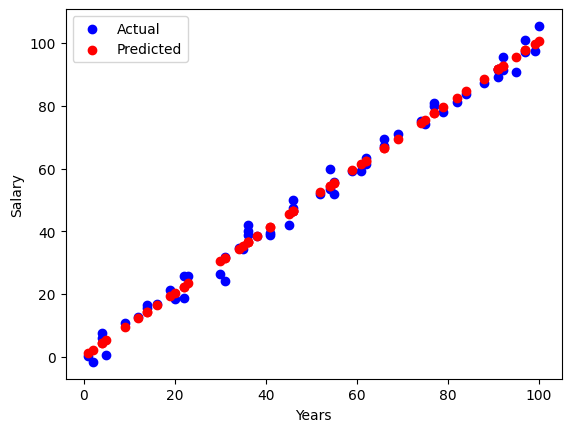

In [318]:
import matplotlib.pyplot as plt

unscaled = scaler.inverse_transform(test_data.T).T
unscaled_predictions = np.zeros((len(predictions), 2)).T
unscaled_predictions[1] = predictions
unscaled_predictions = scaler.inverse_transform(unscaled_predictions.T).T[1]

plt.scatter(unscaled[0].reshape(-1, 1), unscaled[1], label='Actual', color='blue')
plt.scatter(unscaled[0].reshape(-1, 1), unscaled_predictions, label='Predicted', color='red')
plt.xlabel('Years')
plt.ylabel('Salary')
plt.legend()
plt.show()

## Results and conclusions    **(~10%)**

---

(Double click then ...)  Type Here...

---

